# K-means

Vamos pegar uma intuição do k-means inicialmente. Para tanto, vamos gerar algumas bolhas (como se fossem agrupamentos pra entender como o k-means poderia ser usado para agrupar esses dados). 

In [1]:
import numpy as np
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
from sklearn.datasets import make_blobs

/Users/dhenyfernandes/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Agora, vamos criar nossos dados. Especificamos a localização dos centróides e definimos o desvio padrão dos dados para cada cluster

In [2]:
blob_centers = np.array(
    [[ 0.2,  2.3],
     [-1.5 ,  2.3],
     [-2.8,  1.8],
     [-2.8,  2.8],
     [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])

Agora usamos o método make_blobs para criar as bolhas baseadas nas informações que passamos parâmetros. O método retorna os dados gerados bem como o rótulo de cada um (seu cluster).

In [3]:
X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=7)

Podemos criar uma função para visualizar os dados

In [4]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

E agora, fazemos o plot das bolhas:


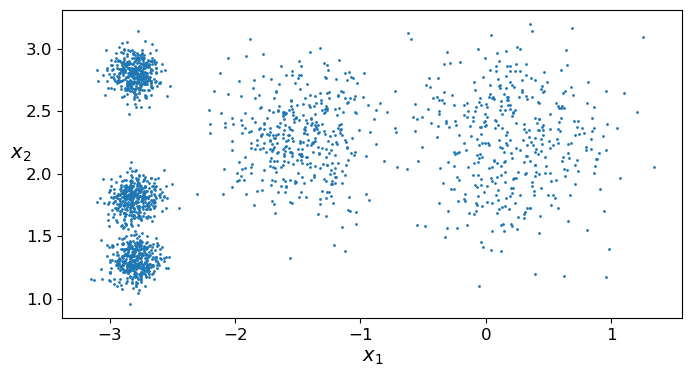

In [5]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

In [6]:
#!pip install --upgrade threadpoolctl scikit-learn

Agora, a ideia é treinar o k-means nesses dados e verificar se ele encontra esses grupos

In [7]:
from sklearn.cluster import KMeans

Para treinar o k-means, definimos o número de k. A partir desses dados, 5 é um número adequado. Entretanto, em problemas reais, a definição de k não é tão simples assim, como já vimos.

In [8]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42,n_init='auto')
y_pred = kmeans.fit_predict(X)

In [9]:
y_pred

array([2, 2, 4, ..., 1, 4, 2], dtype=int32)

In [10]:
blob_centers

array([[ 0.2,  2.3],
       [-1.5,  2.3],
       [-2.8,  1.8],
       [-2.8,  2.8],
       [-2.8,  1.3]])

Podemos comparar os centróides obtidos pelo k-means com os centróides que definimos previamente ao criar os dados. Isso nos dará uma ideia da qualidade dos clusters formados:

In [11]:
kmeans.cluster_centers_

array([[-0.066884  ,  2.10378803],
       [-2.79290307,  2.79641063],
       [-2.80214068,  1.55162671],
       [-1.47468607,  2.28399066],
       [ 0.47042841,  2.41380533]])

Algo interessante de se fazer é plotar as fronteiras de decisão que o algoritmo encontrou e comparar com o plot original dos dados, o que nos permite identificar erros de atribuição a um determinado cluster.

In [12]:
#criando as funções para visualizar as fronteiras de decisão
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

Agora podemos fazer o plot. O que vamos obter é conhecido como Diagrama de Voronoi, uma forma de representar clusters. 

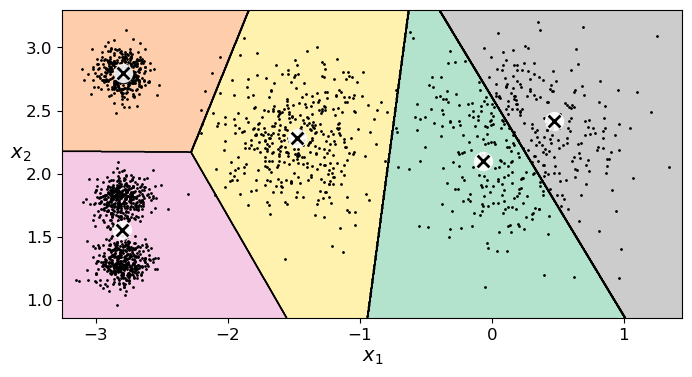

In [13]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

Compare essa figura com a figura original das bolhas. Consegue identificar erros de atribuição?

Fazer a predição de novas amostras é particularmente simples também:

In [14]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([0, 4, 1, 1], dtype=int32)

# O Algoritmo K-means

Depois de entendermos intuitivamente o K-means, é hora de nos aprofundarmos na maneira em que ele constrói clusters.

Suponha que seja fornecido os centróides. Dessa maneira, poderíamos facilmente rotular todas as intâncias no dataset atribuindo a cada uma delas ao cluster cujo centróide seja o mais próximo. 

Alternativamente, se todos os rótulos das amostras foram fornecidos, poderíamos localizar os centróides calculando a média de todas as amostras para cada cluster

Mas e se nada disso for fornecido? 

Podemos posicionar os centróides de maneira aleatória (selecionando k amostras aleatóriamente e usando suas localizações como centróides). Então, rotulamos as instâncias, atualizamos os centróides, rotulamos as instâncias, atualizamos os centróides e assim sucessivamente até que os centróides parem de se mover. 

Vamos executar o K-means para 1, 2 e 3 iterações e ver como os centróides vão se movendo bem como as instâncias atualizando seus rótulos

In [15]:
kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=1, random_state=0)
kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=2, random_state=0)
kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=3, random_state=0)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

,n_clusters,5
,init,'random'
,n_init,1
,max_iter,3
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


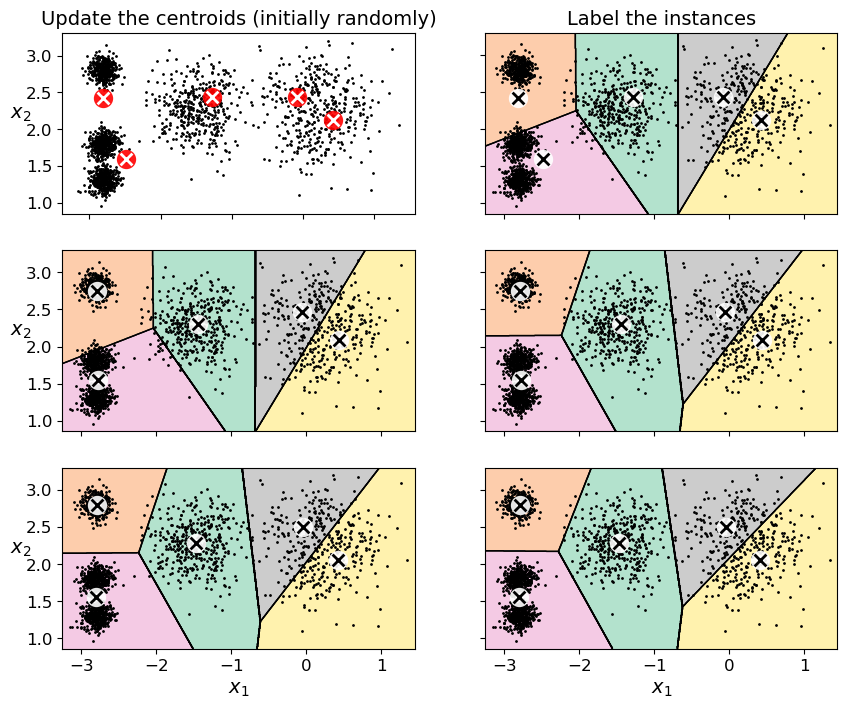

In [16]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

Vimos que, em poucas iterações, o k-means se aproximou da solução ótima. Entretanto, como vimos, o k-means é sensível a inicialização dos centróides, o que signifca que ele pode não convergir para a solução ótima. Vamos entender como podemos encontrar a solução ótima

### Métodos de Inicialização dos Centróides

Se sabemos de antemão onde aproximadamente os centróides devem ser posicionados, podemos setar o parâmetro *init* a partir de um Numpy array e setar *n_init* igual a 1

In [17]:
good_init = np.array([[-3,3],[-3,2],[-3,1],[-1,2],[0,2]])
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1)
kmeans.fit(X)

,n_clusters,5
,init,"array([[-3, ... [ 0, 2]])"
,n_init,1
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


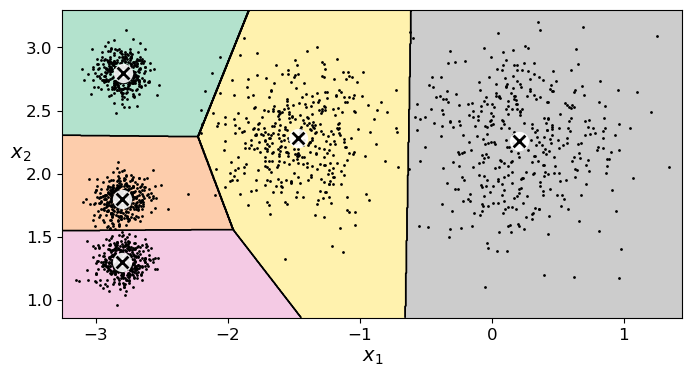

In [18]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

Outra solução é executar o algoritmo múltiplas vezes com diferentes inicializações aleatórias e guardar a melhor solução, mas como sabemos que uma solução é a melhor?

Temos uma métrica de performance que nos fornece essa informação: inercia do modelo, obtida através do parâmetro *inertia_*. Essa métrica nada mais é que distância média quadrática entre cada instância e o centróide mais próximo. 

In [19]:
kmeans.inertia_

211.59853725816836

### Encontrando o número ótimo de clusters

Até o momento, definimos o número de cluster (k) igual a 5 porque é o número óbvio quando se olha os dados. Entretanto, de modo geral, não será fácil saber definir k e os resultados podem ser bem ruins se escolhermos o número incorreto de k. 

Observe o exemplo quando usamos k=3 e depois k=8

In [20]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

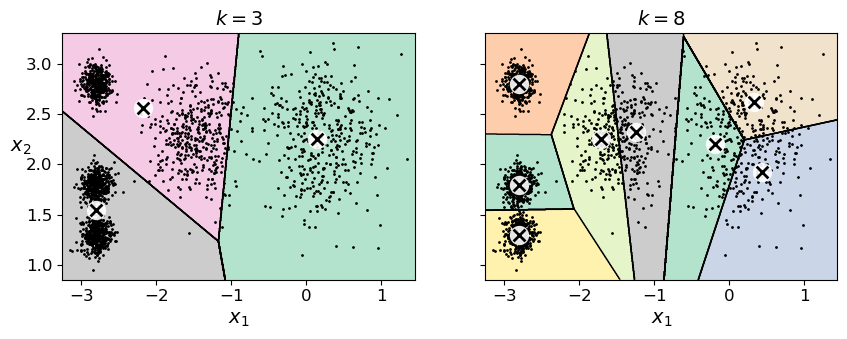

In [21]:
kmeans_k3 = KMeans(n_clusters=3, random_state=42)
kmeans_k8 = KMeans(n_clusters=8, random_state=42)

plot_clusterer_comparison(kmeans_k3, kmeans_k8, X, "$k=3$", "$k=8$")
plt.show()

E se usarmos a inércia para definir o número ótimo de clusters? 

In [22]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

In [23]:
kmeans_per_k

[KMeans(n_clusters=1, random_state=42),
 KMeans(n_clusters=2, random_state=42),
 KMeans(n_clusters=3, random_state=42),
 KMeans(n_clusters=4, random_state=42),
 KMeans(n_clusters=5, random_state=42),
 KMeans(n_clusters=6, random_state=42),
 KMeans(n_clusters=7, random_state=42),
 KMeans(random_state=42),
 KMeans(n_clusters=9, random_state=42)]

In [24]:
inertias

[3534.8360871670793,
 1149.8913501507036,
 653.2167190021553,
 261.79677785694696,
 224.07433122515727,
 173.87609062637864,
 141.79723757580348,
 127.13141880461835,
 109.89175716631655]

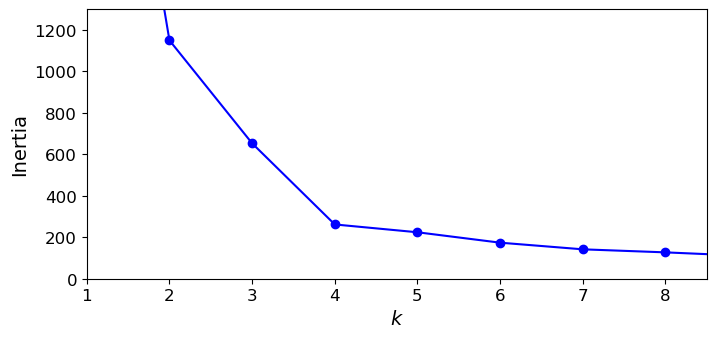

In [25]:
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.axis([1, 8.5, 0, 1300])
plt.show()

Qual o problema dessa solução?

Não podemos simplesmente usar o valor de k que minimiza a inércia visto que ela continuará diminuindo à medida que aumentamos o valor de k. 

De fato, quanto mais clusters existem, mais perto cada instância ficará do seu centróide e, portanto, menor o valor da iníercia. 

#### Elbow

Entretanto, ainda podemos usar a inércia para definir um valor adequado de clusters. Ao analisarmos o gráfico, observamos que o valor na inércia cai drásticamente à medida que aumentamos o valor de k até 4 e, então, o valor da inércia diminui muito mais lentamente a partir daí. Esta curva possui vagamente uma forma de um braço e possui um "cotovelo" (elbow) quando k=4. Assim, poderíamos usar k=4 para uma solução adequada

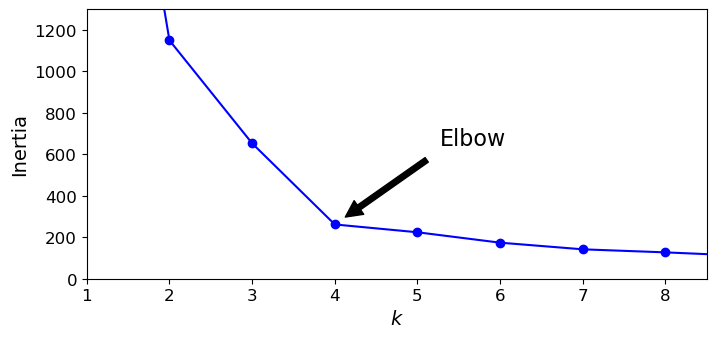

In [26]:
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.annotate('Elbow',
             xy=(4, inertias[3]),
             xytext=(0.55, 0.55),
             textcoords='figure fraction',
             fontsize=16,
             arrowprops=dict(facecolor='black', shrink=0.1)
            )
plt.axis([1, 8.5, 0, 1300])
plt.show()

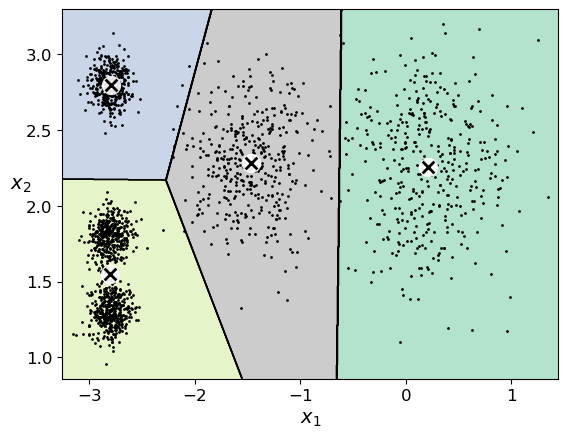

In [27]:
plot_decision_boundaries(kmeans_per_k[4-1], X)
plt.show()

#### Silhouette

Uma outra, e melhor, abordagem para determinar o número de cluster é a partir do *silhouette coefficient*. Como vimos, esse coeficiente é dado pela seguinte equação:

$\frac{(b-a)}{max(a,b)}$

em que:

* a é a distância média para outras amostras no mesmo cluster (distância média intra-cluster)
* 𝑏 é a distância média do cluster mais próximo (distância média para as amostras do próximo cluster mais próximo)

Para calcular o *silhouette score* podemos usar a função de mesmo nome da Scikit-Learn, fornecendo todas as amostras do dataset e seus respectivos rótulos aos quais foram atribuídos:

In [28]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

0.655517642572828

Podemos comparar o valor desse score para diferentes números de clusters:

In [29]:
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

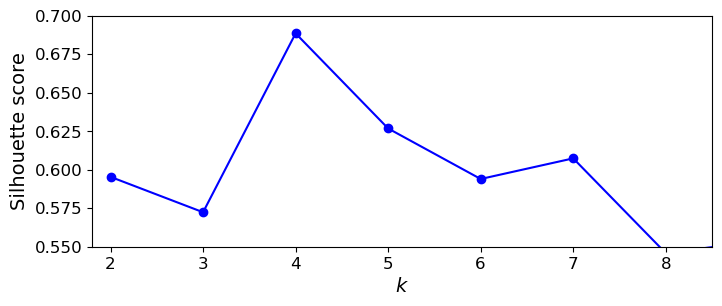

In [30]:
plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.axis([1.8, 8.5, 0.55, 0.7])
plt.show()

Como podemos ver, esta visualização é muito mais rica que a anterior (usando *inertia*). Embora confirme que k=4 é uma ótima escolha (da mesma maneira que o gráfico anterior), mostra também que k=5 é uma excelente opção e muito melhor que k=6 ou k=7, o que não é visível quando usamos inércia.

# Reinforcement Learning

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fixar a semente aleatória é fundamental em Reinforcement Learning (RL) 
# para garantir que os resultados sejam reproduzíveis em sala de aula.
SEED = 7
np.random.seed(SEED)

# Lendo o arquivo CSV do ativo fictício "FICT3"
# O parâmetro parse_dates converte a coluna 'date' automaticamente para o tipo datetime.
df = pd.read_csv("ohlcv_ativo.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)

# Calculando o retorno diário.
# pct_change() calcula a variação percentual em relação à linha anterior (fechamento de hoje / fechamento de ontem - 1).
# fillna(0) lida com o primeiro dia (que não tem dia anterior), atribuindo 0% de retorno.
df["ret"] = df["close"].pct_change().fillna(0)

# Imprimindo as características do dataset (período analisado e a quantidade de dias).
print(f"Periodo: {df['date'].min().date()} -> {df['date'].max().date()} | {len(df)} dias")

# Inspecionando as primeiras linhas.
df.head()

Periodo: 2023-07-10 -> 2026-05-22 | 750 dias


,date,open,high,low,close,volume,ret
0,2023-07-10,25.1593,25.7959,25.0577,25.7682,9704648,0.000000
1,2023-07-11,25.7806,25.8536,25.5432,25.5599,5898811,-0.008084
2,2023-07-12,25.5398,25.7728,25.3448,25.5826,5378341,0.000888
3,2023-07-13,25.5000,25.7877,25.4061,25.7780,2685953,0.007638
4,2023-07-14,25.7003,25.8097,25.4049,25.4196,4733670,-0.013903


Esse conjunto de dados é de 750 pregoes de um ativo fictício chamado FICT3 gerado via Movimento Browniano Geométrico. 

O FICT3 é puro ruído gaussiano. Nao tem padrao real, reversao à média e nem momentum verdadeiro. O objetivo é puramente didático. Na prática, se o agente encontrar padroes, é overfit. 

estamos analisando o retorno por conta do MDP (requer estacionariedade - média e variancia estáveis no tempo). 

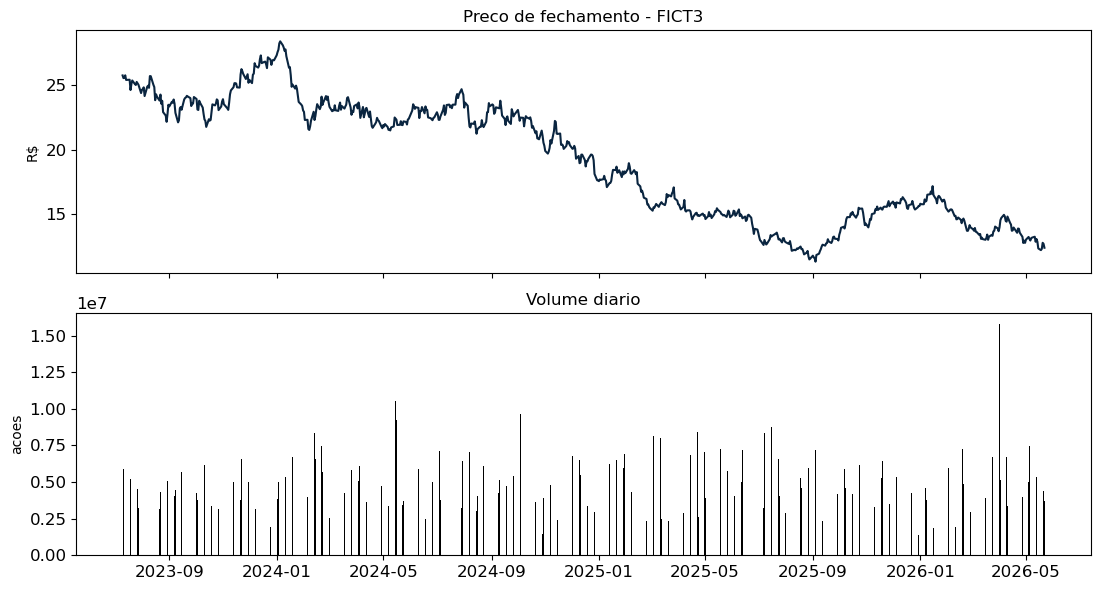

In [33]:
# Criando uma figura com dois eixos (subplots) empilhados. sharex=True garante 
# que eles compartilhem o mesmo eixo X (datas), facilitando a comparação.
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

# Primeiro subplot (axes[0]): Preço de fechamento da ação FICT3
axes[0].plot(df["date"], df["close"], color="#0A2540")
axes[0].set_title("Preco de fechamento - FICT3")
axes[0].set_ylabel("R$")

# Segundo subplot (axes[1]): Volume diário de ações negociadas.
# Usamos um gráfico de barras (bar) em vez de linha para visualizar o volume tradicionalmente.
axes[1].bar(df["date"], df["volume"], color="#000000", width=0.2)
axes[1].set_title("Volume diario")
axes[1].set_ylabel("acoes")

plt.tight_layout() # Ajusta as margens para não haver sobreposição.
plt.show()

2. Ambiente: Estado, Ação, Recompensa
¶


Estado
 $s$: quintil da média móvel 5d dos retornos (5 estados discretos)


Ação
 $a$: 0 = flat, 1 = long, 2 = short


Recompensa
 $r$: retorno do dia seguinte com sinal conforme a ação


Horizonte
: 1 dia (decisão diária)

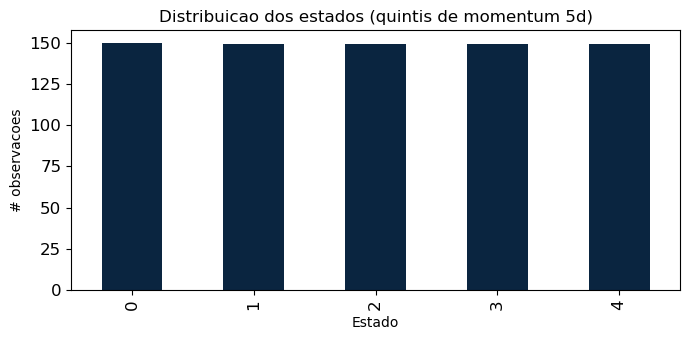

In [34]:
# Calculamos o momento (tendência) dos últimos 5 dias por meio de uma Média Móvel 
# (rolling) sobre a coluna de retornos diários.
df["mom5"] = df["ret"].rolling(5).mean() 

# O Q-Learning clássico não lida bem com estados contínuos. Precisamos de estados "discretos".
# pd.qcut divide o momentum de 5 dias em 5 "cestas" (quintis) com tamanho estatisticamente similar.
# labels=False força a saída a ser valores inteiros: 0, 1, 2, 3 e 4.
df["state"] = pd.qcut(df["mom5"], q=5, labels=False)

# O cálculo do rolling gera NaNs nas 4 primeiras linhas. Precisamos removê-las para o RL não quebrar.
df = df.dropna().reset_index(drop=True)
df["state"] = df["state"].astype(int) # Garantindo que o estado é um número inteiro

# Plotando a distribuição dos estados para confirmar se o qcut balanceou bem as observações.
fig, ax = plt.subplots(figsize=(7, 3.5))
df["state"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#0A2540")
ax.set_title("Distribuicao dos estados (quintis de momentum 5d)")
ax.set_xlabel("Estado")
ax.set_ylabel("# observacoes")
plt.tight_layout()
plt.show()

# Resumo dos estados (como o modelo enxergará o mercado):
# 0 - forte queda
# 1 - queda leve
# 2 - lateral (sem forte direção)
# 3 - alta leve
# 4 - forte alta

3. Q-Learning Tabular
¶

In [35]:
# Variáveis e hiperparâmetros do processo de Decisão de Markov (MDP)
n_states  = 5
n_actions = 3   # O agente terá 3 botões: 0 = Ficar de fora (flat), 1 = Comprar (long), 2 = Vender a descoberto (short)
alpha     = 0.10 # Learning Rate (Taxa de aprendizado): quanto da nova informação substitui a antiga
gamma     = 0.95 # Discount Factor: importância dada a recompensas futuras vs imediatas (próximo a 1 = longo prazo)

# Parâmetros de exploração (Epsilon-Greedy). 
# O agente começa explorando ações aleatórias (30%) e aos poucos se baseia apenas no que aprendeu (1%).
eps_start, eps_end = 0.30, 0.01 
n_episodes = 300 # Um episódio = percorrer a base de dados de treinamento inteira.

# Dividindo a base entre Treino (70%) e Teste (Out-of-sample) (30%)
split = int(0.7 * len(df))
train = df.iloc[:split].reset_index(drop=True)
test  = df.iloc[split:].reset_index(drop=True)

# Função de recompensa (Reward). A forma como o agente é pontuado pelas suas ações.
def reward(action, ret_next):
    if action == 1: return ret_next    # Se comprou (long), a recompensa é o retorno do dia seguinte.
    if action == 2: return -ret_next   # Se vendeu (short), lucra se o ativo cair (recompensa é o retorno invertido).
    return 0.0                         # Se ficou flat (fora), não ganha e não perde.

# Inicializando a "Mente" do agente: A Q-Table. Uma matriz preenchida com Zeros.
# Teremos 5 linhas (estados) x 3 colunas (ações).
Q = np.zeros((n_states, n_actions))
returns_per_episode = []

# Loop principal: Treinando através dos episódios
for ep in range(n_episodes):
    # Decaimento linear do epsilon. A cada episódio o agente explora um pouco menos aleatoriamente.
    eps = eps_end + (eps_start - eps_end) * (1 - ep / n_episodes)
    ep_reward = 0.0
    
    # Percorrendo cada dia da base de treinamento
    for i in range(len(train) - 1):
        # iat é usado para buscar um valor único de forma extremamente rápida.
        s      = int(train["state"].iat[i])      # Estado de hoje
        s_next = int(train["state"].iat[i+1])    # Estado de amanhã (necessário para o termo gamma * max(Q))
        r_next = float(train["ret"].iat[i+1])    # O retorno real que ocorreu no dia seguinte

        # Epsilon-Greedy: Escolha da Ação
        if np.random.rand() < eps:
            a = np.random.randint(n_actions)     # Exploração: Escolhe ação 0, 1 ou 2 de forma aleatória
        else:
            a = int(np.argmax(Q[s]))             # Explotação: Escolhe a ação que tem o maior valor esperado (maior Q) para o estado atual

        # Passo do Agente (Step)
        r = reward(a, r_next)                    # Calcula o quanto ganhou/perdeu
        
        # Atualização da Q-Table
        # Novo_Q = Q_Antigo + alpha * (recompensa_imediata + (gamma * maior_valor_futuro) - Q_Antigo)
        Q[s, a] += alpha * (r + gamma * Q[s_next].max() - Q[s, a])
        
        ep_reward += r
        
    returns_per_episode.append(ep_reward)

print("Q-table final:")
print(np.round(Q, 4))

Q-table final:
[[ 0.008   0.0002  0.0058]
 [ 0.0086  0.0064  0.0061]
 [ 0.0103  0.0035  0.0071]
 [ 0.0108  0.0005 -0.0017]
 [ 0.0051  0.0058  0.0208]]


Detalhando a equacao de Bellman:

* $\alpha$: taxa de aprendizado - o quanto a nova info atualiza a tabela
* $\gamma$: fator de desconto - quanto valorizo recompensas futuras
* $r$: recompensa imediada observada (d+1)
* $\max_{a'}Q(s',a')$: melhor valor esperado a partir do próximo estado

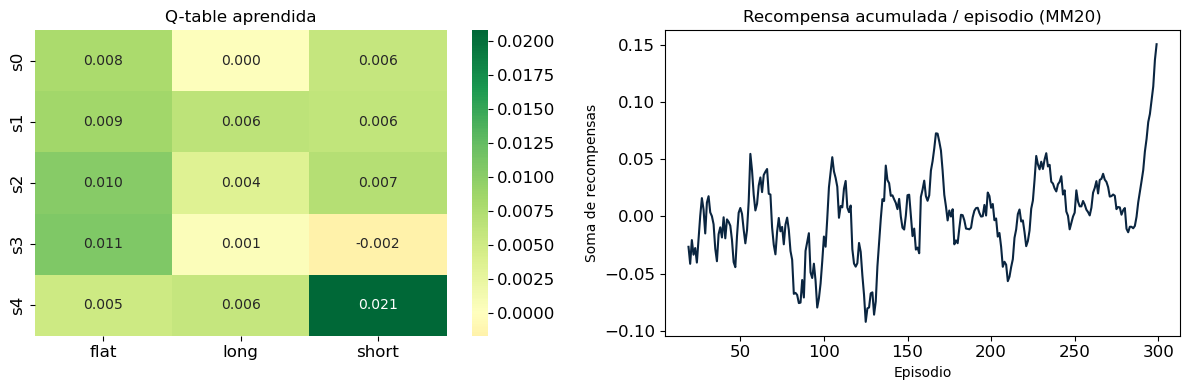

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Primeiro gráfico: Mapa de calor da Q-Table. 
# O que o agente efetivamente "decorou".
sns.heatmap(Q, annot=True, fmt=".3f", cmap="RdYlGn", center=0,
            xticklabels=["flat","long","short"],
            yticklabels=[f"s{i}" for i in range(n_states)], ax=axes[0])
axes[0].set_title("Q-table aprendida")

# Segundo gráfico: Convergência da recompensa.
# Exibe a pontuação total por episódio. Uma curva ascendente significa que ele está aprendendo.
# Aplicamos uma média móvel de 20 episódios (rolling) para suavizar a curva de aprendizado (tirar ruídos de exploração).
axes[1].plot(pd.Series(returns_per_episode).rolling(20).mean(), color="#0A2540")
axes[1].set_title("Recompensa acumulada / episodio (MM20)")
axes[1].set_xlabel("Episodio")
axes[1].set_ylabel("Soma de recompensas")
plt.tight_layout()
plt.show()

4. Avaliação Out-of-Sample
¶

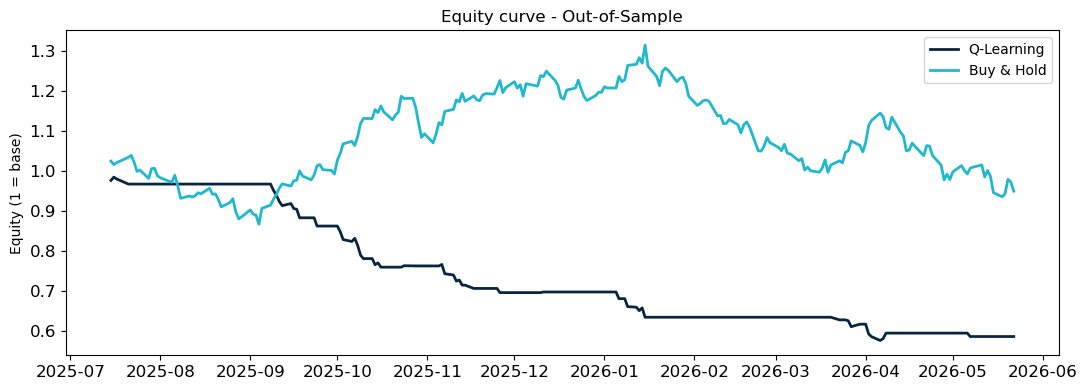

In [37]:
test = test.copy()

# Em modo "produção/teste", o agente não explora (epsilon = 0). Ele toma a decisão pura da tabela aprendida.
test["action"] = test["state"].map(lambda s: int(np.argmax(Q[int(s)]))) 

# Simulando os lucros baseado na ação escolhida
test["strategy_ret"] = test.apply(lambda r: reward(int(r["action"]), float(r["ret"])), axis=1)

# Cumprod (Produto Cumulativo): Transforma os retornos percentuais na evolução financeira do capital (Equity Curve).
test["equity_rl"] = (1 + test["strategy_ret"]).cumprod()
test["equity_bh"] = (1 + test["ret"]).cumprod() # Como teria sido se apenas comprasse o ativo e não fizesse nada (Buy & Hold).

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(test["date"], test["equity_rl"], label="Q-Learning", color="#0A2540", linewidth=2)
ax.plot(test["date"], test["equity_bh"], label="Buy & Hold", color="#1FB8CD", linewidth=2)
ax.set_title("Equity curve - Out-of-Sample")
ax.set_ylabel("Equity (1 = base)")
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
# Cálculo do Índice de Sharpe Anualizado (mede a relação risco-retorno)
def sharpe(returns, periods=252):
    mu = returns.mean() * periods
    sd = returns.std() * (periods ** 0.5)
    return mu / sd if sd > 0 else 0.0

# Max Drawdown indica a maior perda consecutiva do topo ao fundo
def max_drawdown(equity):
    peak = equity.cummax()            # Vai salvando os topos históricos
    dd = (equity / peak) - 1          # Subtração simples para ver a queda do último topo
    return dd.min()                   # Retorna a maior queda (o valor mais negativo)

metrics = pd.DataFrame({
    "Q-Learning": [sharpe(test["strategy_ret"]), max_drawdown(test["equity_rl"]), test["equity_rl"].iloc[-1] - 1],
    "Buy & Hold": [sharpe(test["ret"]),          max_drawdown(test["equity_bh"]), test["equity_bh"].iloc[-1] - 1],
}, index=["Sharpe (anual)", "Max Drawdown", "Retorno total"])

# Imprime o DataFrame para comparativo entre o robô RL e a estratégia estática
print(metrics.round(3))

                Q-Learning  Buy & Hold
Sharpe (anual)      -4.821      -0.070
Max Drawdown        -0.414      -0.288
Retorno total       -0.414      -0.051


* sharpe anualizado = (retorno medio anualizado)/(volatilidade anualizada)
* Max Drawndown = pior queda acumulada do pico ao vale. 

5. Análise de Sensibilidade
¶

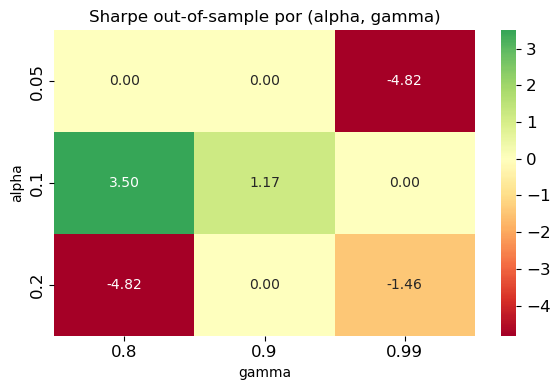

In [39]:
# Vamos testar de forma exaustiva quais seriam os melhores valores para Alpha e Gamma
alphas = [0.05, 0.10, 0.20]
gammas = [0.80, 0.90, 0.99]
grid   = np.zeros((len(alphas), len(gammas)))

for ia, a_lr in enumerate(alphas):
    for ig, g_df in enumerate(gammas):
        Q2 = np.zeros((n_states, n_actions)) # Uma Q-Table em branco para cada combinação
        
        # Treinamento reduzido (150 episódios e Epsilon fixo em 10% por questões de agilidade no GridSearch)
        for ep in range(150):
            eps = 0.1
            for i in range(len(train) - 1):
                s   = int(train["state"].iat[i])
                s_n = int(train["state"].iat[i+1])
                r_n = float(train["ret"].iat[i+1])
                
                # Epsilon-Greedy
                if np.random.rand() < eps:
                    a = np.random.randint(n_actions)
                else:
                    a = int(np.argmax(Q2[s]))
                r = reward(a, r_n)
                
                # Atualização Q-Table usando a_lr e g_df dinâmicos do loop
                Q2[s, a] += a_lr * (r + g_df * Q2[s_n].max() - Q2[s, a])
        
        # Coleta das métricas (no dataset de teste) para o modelo da vez
        acts = test["state"].map(lambda s: int(np.argmax(Q2[int(s)])))
        rets = [reward(int(a), float(r)) for a, r in zip(acts, test["ret"])]
        
        # Salvamos o Índice de Sharpe no grid correspondente
        grid[ia, ig] = sharpe(pd.Series(rets))

# Plotando os resultados do Grid Search para definir os melhores parâmetros visualmente
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(grid, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            xticklabels=gammas, yticklabels=alphas, ax=ax)
ax.set_xlabel("gamma")
ax.set_ylabel("alpha")
ax.set_title("Sharpe out-of-sample por (alpha, gamma)")
plt.tight_layout()

Em dados reais:

* $\alpha$ muito alto: instável
* $\alpha$ muito baixo: nao converge
* $\gamma$ alto: boa visao de longo prazo
* $\gamma$ baixo: míope